In [6]:
import numpy as np
import tsim
import stim
import matplotlib.pyplot as plt
def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    """
    Compute the physical rotation angle needed to achieve a logical rotation of
    angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

    Args:
        logical_angle_in_pi (float): The logical rotation angle in units of pi.
        num_physical_rotations (int): The number of physical rotations that are applied.
    Returns:
        float: The physical rotation angle in units of pi.
    """

    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)

In [7]:
c1 = tsim.Circuit.from_file("../assets/star_circuits/star_d=3.stim")
c1.diagram("timeslice-svg", height=2000)

[0.0001     0.00023101 0.00053367 0.00123285 0.00284804 0.00657933
 0.01519911 0.03511192 0.08111308 0.18738174 0.43287613 1.        ]
Logical theta = 0.0001 pi
Physical theta = -0.03431619815037743 pi
Acceptance rate = 6.918600e-01
Logical error rate = 0.000000e+00
Logical theta = 0.00023101297000831605 pi
Physical theta = -0.04533121270672316 pi
Acceptance rate = 6.892100e-01
Logical error rate = 0.000000e+00
Logical theta = 0.0005336699231206312 pi
Physical theta = -0.059849737701731534 pi
Acceptance rate = 6.791100e-01
Logical error rate = 0.000000e+00
Logical theta = 0.0012328467394420659 pi
Physical theta = -0.07894461088014712 pi
Acceptance rate = 6.658100e-01
Logical error rate = 4.505790e-05
Logical theta = 0.002848035868435802 pi
Physical theta = -0.10396438139804229 pi
Acceptance rate = 6.425300e-01
Logical error rate = 1.245078e-04
Logical theta = 0.006579332246575682 pi
Physical theta = -0.13653826902765548 pi
Acceptance rate = 6.089000e-01
Logical error rate = 6.733454e-0

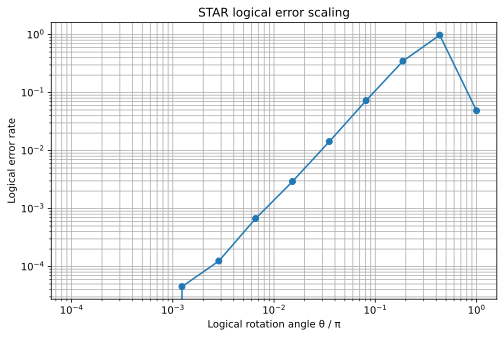

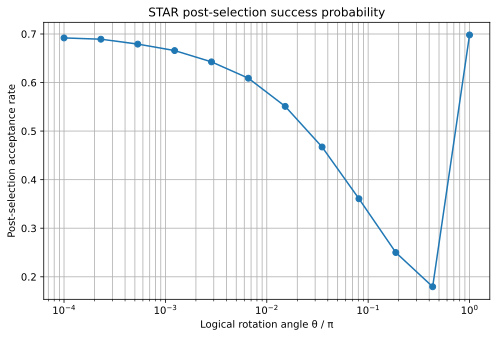

In [ ]:


with open("star_circuits/star_d=3.stim", "r") as f:
    TEMPLATE = f.read()

logical_thetas = np.logspace(-4, 0, 12)
print (logical_thetas)
shots = 100_000

logical_error_rates = []
acceptance_rates = []


for theta_logical in logical_thetas:


    theta_phys = physical_angle(theta_logical, 3)
    print("=" * 60)
    print(f"Logical theta = {theta_logical} pi")
    print(f"Physical theta = {theta_phys / np.pi} pi")

    circuit_text = TEMPLATE

    circuit_text = circuit_text.replace(
        "PHYSICAL_ROTATION_HERE",
        f"R_Z({theta_phys}) 0 3 6"
    )

    circuit_text = circuit_text.replace(
        "LOGICAL_UNROTATION_HERE",
        f"R_Z({-theta_logical * np.pi}) 6"
    )


    circuit = tsim.Circuit(circuit_text)


    num_detectors = circuit.num_detectors
    num_observables = circuit.num_observables


    sampler = circuit.compile_detector_sampler()

    data = sampler.sample(
        shots,
        separate_observables=True
    )

    detectors = data[0]
    observables = data[1]


    accepted_mask = np.all(detectors == 0, axis=1)

    accepted_observables = observables[accepted_mask]

    acceptance_rate = np.mean(accepted_mask)

    if len(accepted_observables) == 0:
        logical_error_rate = np.nan
    else:
        logical_error_rate = np.mean(
            accepted_observables[:, 0]
        )


    print(f"Acceptance rate = {acceptance_rate:.6e}")
    print(f"Logical error rate = {logical_error_rate:.6e}")


    logical_error_rates.append(logical_error_rate)
    acceptance_rates.append(acceptance_rate)



plt.figure(figsize=(8, 5))

plt.loglog(
    logical_thetas,
    logical_error_rates,
    marker='o'
)

plt.xlabel("Logical rotation angle θ / π")
plt.ylabel("Logical error rate")
plt.title("STAR logical error scaling")
plt.grid(True, which='both')

plt.show()


# ============================================================
# PLOT: ACCEPTANCE RATE
# ============================================================

plt.figure(figsize=(8, 5))

plt.semilogx(
    logical_thetas,
    acceptance_rates,
    marker='o'
)

plt.xlabel("Logical rotation angle θ / π")
plt.ylabel("Post-selection acceptance rate")
plt.title("STAR post-selection success probability")
plt.grid(True, which='both')

plt.show()

In [12]:
with open("star_circuits/star_d=5.stim", "r") as f:
    TEMPLATE = f.read()

logical_thetas2 = np.logspace(-4, 0, 12)

shots = 100_000

logical_error_rates2 = []
acceptance_rates2 = []


for theta_logical in logical_thetas2:


    theta_phys2 = physical_angle(theta_logical, 3)

    print("=" * 60)
    print(f"Logical theta = {theta_logical} pi")
    print(f"Physical theta = {theta_phys2 / np.pi} pi")

    circuit_text = TEMPLATE

    # Stim expects radians
    circuit_text = circuit_text.replace(
        "PHYSICAL_ROTATION_HERE",
        f"R_Z({theta_phys2}) 0 5 10 15 20"
    )

    circuit_text = circuit_text.replace(
        "LOGICAL_UNROTATION_HERE",
        f"R_Z({-theta_logical * np.pi}) 6"
    )


    circuit2 = tsim.Circuit(circuit_text)


    num_detectors2 = circuit2.num_detectors
    num_observables2 = circuit2.num_observables


    sampler2 = circuit2.compile_detector_sampler()

    data = sampler2.sample(
        shots,
        separate_observables=True
    )

    detectors2 = data[0]
    observables2 = data[1]


    accepted_mask = np.all(detectors2 == 0, axis=1)

    accepted_observables2 = observables2[accepted_mask]

    acceptance_rate2 = np.mean(accepted_mask)

    if len(accepted_observables2) == 0:
        logical_error_rate2 = np.nan
    else:
        logical_error_rate2 = np.mean(
            accepted_observables2[:, 0]
        )


    print(f"Acceptance rate = {acceptance_rate2:.6e}")
    print(f"Logical error rate = {logical_error_rate2:.6e}")


    logical_error_rates2.append(logical_error_rate2)
    acceptance_rates2.append(acceptance_rate2)


Logical theta = 0.0001 pi
Physical theta = -0.010923185127507049 pi
Acceptance rate = 2.795800e-01
Logical error rate = 0.000000e+00
Logical theta = 0.00023101297000831605 pi
Physical theta = -0.014429373157250255 pi
Acceptance rate = 2.789300e-01
Logical error rate = 0.000000e+00
Logical theta = 0.0005336699231206312 pi
Physical theta = -0.01905076319596789 pi
Acceptance rate = 2.735700e-01
Logical error rate = 0.000000e+00
Logical theta = 0.0012328467394420659 pi
Physical theta = -0.025128850104083274 pi
Acceptance rate = 2.629900e-01
Logical error rate = 0.000000e+00
Logical theta = 0.002848035868435802 pi
Physical theta = -0.033092890409979044 pi
Acceptance rate = 2.495500e-01
Logical error rate = 0.000000e+00
Logical theta = 0.006579332246575682 pi
Physical theta = -0.04346148087392481 pi
Acceptance rate = 2.275500e-01
Logical error rate = 0.000000e+00
Logical theta = 0.01519911082952933 pi
Physical theta = -0.056816779493245324 pi
Acceptance rate = 1.907600e-01
Logical error rate

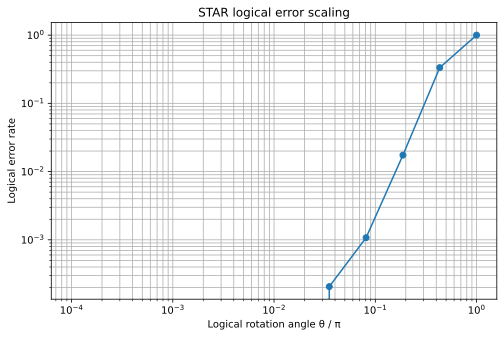

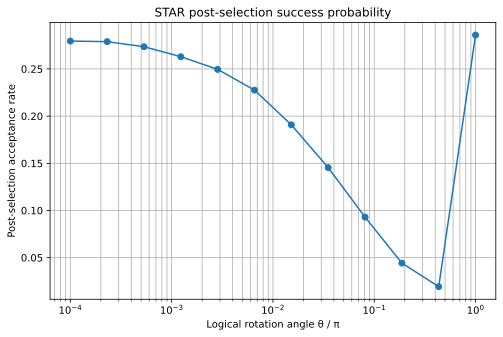

In [13]:

plt.figure(figsize=(8, 5))

plt.loglog(
    logical_thetas2,
    logical_error_rates2,
    marker='o'
)

plt.xlabel("Logical rotation angle θ / π")
plt.ylabel("Logical error rate")
plt.title("STAR logical error scaling")
plt.grid(True, which='both')

plt.show()


# ============================================================
# PLOT: ACCEPTANCE RATE
# ============================================================

plt.figure(figsize=(8, 5))

plt.semilogx(
    logical_thetas2,
    acceptance_rates2,
    marker='o'
)

plt.xlabel("Logical rotation angle θ / π")
plt.ylabel("Post-selection acceptance rate")
plt.title("STAR post-selection success probability")
plt.grid(True, which='both')

plt.show()

In [ ]:
CODE_DATA = {
    3: {
        "logical_z_qubits": [0,3,6],
        "logical_measurement_qubit": 6,
    },

    5: {
        "logical_z_qubits": [0, 5, 10, 15, 20],
        "logical_measurement_qubit": 20,
    },
    
    7: {
        "logical_z_qubits": [0, 7, 14, 21, 28, 35, 42],
        "logical_measurement_qubit": 42,
    },

    9: {
        "logical_z_qubits": [0, 9, 18, 27, 36, 45, 54, 63, 72],
        "logical_measurement_qubit": 72,
    },

    11: {
        "logical_z_qubits": [0, 11, 22, 33, 44, 55, 66, 77, 88, 99, 110],
        "logical_measurement_qubit": 110,
    },

    13: {
        "logical_z_qubits": [0, 13, 26, 39, 52, 65, 78, 91, 104, 117, 130, 143, 156],
        "logical_measurement_qubit": 156,
    },

    15: {
        "logical_z_qubits": [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210],
        "logical_measurement_qubit": 210,
    },
}


# ============================================================
# THETA SWEEP
# ============================================================

logical_thetas = np.logspace(-4, 0, 12)


# ============================================================
# SIMULATION PARAMETERS
# ============================================================

shots = 100_000


# ============================================================
# STORAGE
# ============================================================

all_results = {}
all_acceptance = {}


# ============================================================
# MAIN DISTANCE LOOP
# ============================================================

for distance in [3, 5, 7]:

    print("\n" + "="*80)
    print(f"DISTANCE d = {distance}")
    print("="*80)


    z_qubits = CODE_DATA[distance]["logical_z_qubits"]
    logical_measurement_qubit = CODE_DATA[distance][
        "logical_measurement_qubit"
    ]


    num_rotations = len(z_qubits)


    rotation_targets = " ".join(map(str, z_qubits))


    logical_errors = []
    acceptance_rates = []


    # --------------------------------------------------------
    # LOAD TEMPLATE
    # --------------------------------------------------------

    filename = f"star_circuits\star_d={distance}.stim"

    with open(filename, "r") as f:
        template = f.read()


    # ========================================================
    # THETA LOOP
    # ========================================================

    for theta_logical in logical_thetas:

        theta_phys = physical_angle(
            theta_logical,
            num_rotations
        )


        # ----------------------------------------------------
        # INSERT PHYSICAL ROTATION
        # ----------------------------------------------------

        physical_rotation_instruction = (
            f"R_Z({theta_phys}) {rotation_targets}"
        )


        # ----------------------------------------------------
        # INSERT LOGICAL UNROTATION
        # ----------------------------------------------------

        logical_unrotation_instruction = (
            f"R_Z({-theta_logical*np.pi}) "
            f"{logical_measurement_qubit}"
        )


        # ----------------------------------------------------
        # BUILD CIRCUIT
        # ----------------------------------------------------

        circuit_text = template

        circuit_text = circuit_text.replace(
            "PHYSICAL_ROTATION_HERE",
            physical_rotation_instruction
        )

        circuit_text = circuit_text.replace(
            "LOGICAL_UNROTATION_HERE",
            logical_unrotation_instruction
        )


        circuit = tsim.Circuit(circuit_text)


        # ----------------------------------------------------
        # SAMPLE
        # ----------------------------------------------------

        sampler = circuit.compile_detector_sampler()

        data = sampler.sample(
            shots,
            separate_observables=True
        )

        detectors = data[0]
        observables = data[1]


        # ----------------------------------------------------
        # POST-SELECTION
        # ----------------------------------------------------

        accepted_mask = np.all(detectors == 0, axis=1)

        accepted_observables = observables[
            accepted_mask
        ]


        # ----------------------------------------------------
        # ACCEPTANCE RATE
        # ----------------------------------------------------

        acceptance_rate = np.mean(accepted_mask)


        # ----------------------------------------------------
        # LOGICAL ERROR RATE
        # ----------------------------------------------------

        if len(accepted_observables) == 0:
            logical_error_rate = np.nan
        else:
            logical_error_rate = np.mean(
                accepted_observables[:, 0]
            )


        print(
            f"theta={theta_logical:.3e} "
            f"accept={acceptance_rate:.3e} "
            f"logical={logical_error_rate:.3e}"
        )


        logical_errors.append(logical_error_rate)
        acceptance_rates.append(acceptance_rate)


    all_results[distance] = logical_errors
    all_acceptance[distance] = acceptance_rates




<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
C:\Users\nicco\AppData\Local\Temp\ipykernel_268\3542011620.py:92: SyntaxWarning: invalid escape sequence '\s'
  filename = f"star_circuits\star_d={distance}.stim"



DISTANCE d = 3
theta=1.000e-04 accept=6.925e-01 logical=0.000e+00
theta=2.310e-04 accept=6.876e-01 logical=1.454e-05
theta=5.337e-04 accept=6.786e-01 logical=1.474e-05
theta=1.233e-03 accept=6.646e-01 logical=1.505e-05
theta=2.848e-03 accept=6.403e-01 logical=9.371e-05
theta=6.579e-03 accept=6.068e-01 logical=4.615e-04
theta=1.520e-02 accept=5.484e-01 logical=2.389e-03
theta=3.511e-02 accept=4.666e-01 logical=1.363e-02
theta=8.111e-02 accept=3.561e-01 logical=7.118e-02
theta=1.874e-01 accept=2.473e-01 logical=3.451e-01
theta=4.329e-01 accept=1.778e-01 logical=9.819e-01
theta=1.000e+00 accept=6.985e-01 logical=4.775e-02

DISTANCE d = 5
theta=1.000e-04 accept=2.470e-01 logical=0.000e+00
theta=2.310e-04 accept=2.297e-01 logical=0.000e+00
theta=5.337e-04 accept=2.162e-01 logical=0.000e+00
theta=1.233e-03 accept=1.897e-01 logical=0.000e+00
theta=2.848e-03 accept=1.659e-01 logical=1.808e-04
theta=6.579e-03 accept=1.369e-01 logical=4.383e-04
theta=1.520e-02 accept=1.038e-01 logical=2.793e-03

ValueError: 
Logical angle $\\theta / \\pi$
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

<Figure size 1000x600 with 1 Axes>

ValueError: 
Logical angle $\\theta / \\pi$
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

<Figure size 1000x600 with 1 Axes>

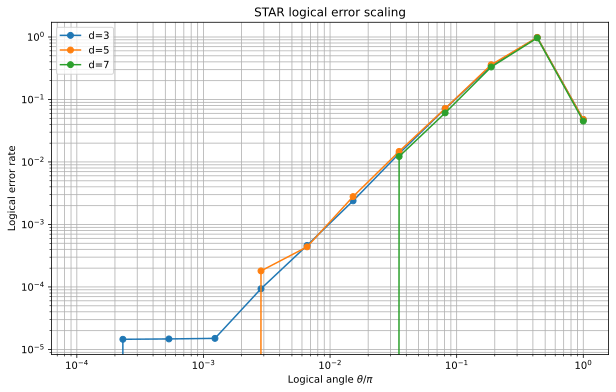

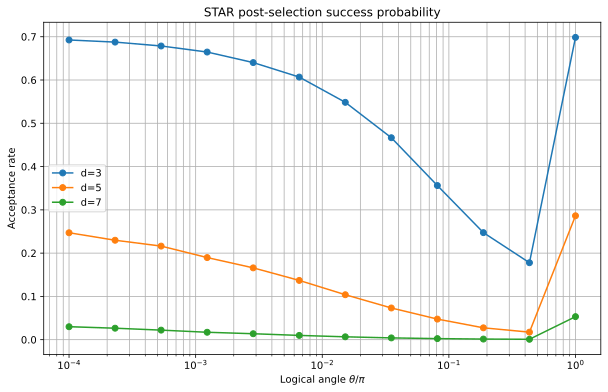

In [9]:
plt.figure(figsize=(10, 6))

for distance in [3, 5, 7]:

    plt.loglog(
        logical_thetas,
        all_results[distance],
        marker='o',
        label=f'd={distance}'
    )


plt.xlabel(r'Logical angle $\theta / \pi$')
plt.ylabel('Logical error rate')
plt.title('STAR logical error scaling')
plt.grid(True, which='both')
plt.legend()

plt.show()


# ============================================================
# PLOT 2: ACCEPTANCE RATE
# ============================================================

plt.figure(figsize=(10, 6))

for distance in [3, 5, 7]:

    plt.semilogx(
        logical_thetas,
        all_acceptance[distance],
        marker='o',
        label=f'd={distance}'
    )


plt.xlabel(r'Logical angle $\theta / \pi$')
plt.ylabel('Acceptance rate')
plt.title('STAR post-selection success probability')
plt.grid(True, which='both')
plt.legend()

plt.show()

In [14]:
print(circuit.num_qubits)
print(circuit2.num_qubits)

17
49
